In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ruta = r"C:\Users\aezdu\OneDrive\Escritorio\SYB66.csv"

# 1. Cargar el archivo saltando la primera fila
df = pd.read_csv(ruta, encoding="latin1", skiprows=1)

In [2]:
print(df.head())

   Region/Country/Area                     Unnamed: 1  Year  \
0                    1  Total, all countries or areas  2010   
1                    1  Total, all countries or areas  2010   
2                    1  Total, all countries or areas  2010   
3                    1  Total, all countries or areas  2010   
4                    1  Total, all countries or areas  2010   

                                              Series Value Footnotes  \
0       Population annual rate of increase (percent)   1.3       NaN   
1          Total fertility rate (children per women)   2.6       NaN   
2  Infant mortality for both sexes (per 1,000 liv...  37.1       NaN   
3  Maternal mortality ratio (deaths per 100,000 p...   254       NaN   
4    Life expectancy at birth for both sexes (years)  70.1       NaN   

                                              Source  
0  United Nations Population Division, New York, ...  
1  United Nations Population Division, New York, ...  
2  United Nations Stati

In [4]:
print(df.columns.tolist())

['Region/Country/Area', 'Unnamed: 1', 'Year', 'Series', 'Value', 'Footnotes', 'Source']


In [6]:
df.head()

,Region/Country/Area,Unnamed: 1,Year,Series,Value,Footnotes,Source
0,1,"Total, all countries or areas",2010,Population annual rate of increase (percent),1.3,NaN,"United Nations Population Division, New York, ..."
1,1,"Total, all countries or areas",2010,Total fertility rate (children per women),2.6,NaN,"United Nations Population Division, New York, ..."
2,1,"Total, all countries or areas",2010,"Infant mortality for both sexes (per 1,000 liv...",37.1,NaN,"United Nations Statistics Division, New York, ..."
3,1,"Total, all countries or areas",2010,"Maternal mortality ratio (deaths per 100,000 p...",254,NaN,"World Health Organization (WHO), the United Na..."
4,1,"Total, all countries or areas",2010,Life expectancy at birth for both sexes (years),70.1,NaN,"United Nations Population Division, New York, ..."


In [7]:
# Renombrar la columna Unnamed: 1 
df = df.rename(columns={"Unnamed: 1": "Area"})

In [8]:
df.head()

,Region/Country/Area,Area,Year,Series,Value,Footnotes,Source
0,1,"Total, all countries or areas",2010,Population annual rate of increase (percent),1.3,NaN,"United Nations Population Division, New York, ..."
1,1,"Total, all countries or areas",2010,Total fertility rate (children per women),2.6,NaN,"United Nations Population Division, New York, ..."
2,1,"Total, all countries or areas",2010,"Infant mortality for both sexes (per 1,000 liv...",37.1,NaN,"United Nations Statistics Division, New York, ..."
3,1,"Total, all countries or areas",2010,"Maternal mortality ratio (deaths per 100,000 p...",254,NaN,"World Health Organization (WHO), the United Na..."
4,1,"Total, all countries or areas",2010,Life expectancy at birth for both sexes (years),70.1,NaN,"United Nations Population Division, New York, ..."


In [9]:
# Limpiar la columna 'Value' (quitar comas y convertir a número)
df["Value"] = df["Value"].astype(str).str.replace(",", "")
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

In [10]:
# Filtramos las series que nos interesan

serie_mortalidad = (
    "Infant mortality for both sexes (per 1,000 live births)"
)
serie_esperanza = "Life expectancy at birth for both sexes (years)"

df_filtrado = df[df["Series"].isin([serie_mortalidad, serie_esperanza])]

In [11]:
df_filtrado = df_filtrado[df_filtrado["Year"] == 2020]

In [15]:
# Transformamos las filas de 'Series' en columnas individuales

df_pivot = df_filtrado.pivot_table(
    index=["Area", "Year"], columns="Series", values="Value"
).reset_index()

df_pivot.columns.name = None

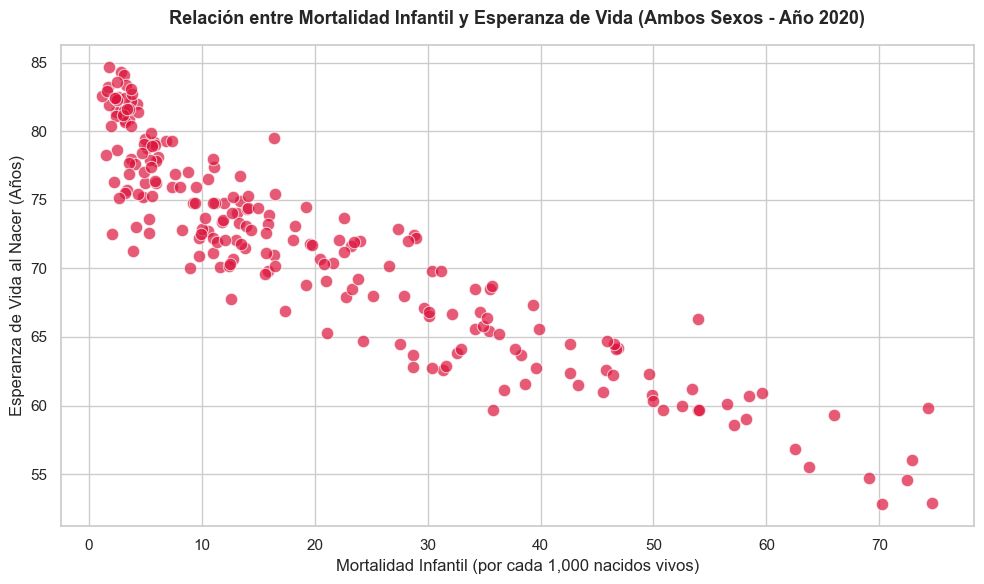

In [16]:
# Creamos el gráfico de dispersión para el año 2020

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Graficamos los puntos del año 2020
sns.scatterplot(
    data=df_pivot,
    x=serie_mortalidad,
    y=serie_esperanza,
    s=80,  # Tamaño de los puntos un poco más grande
    color="crimson",  # Todos los países en un solo color elegante para evitar saturación
    alpha=0.7,
)

# Personalización del gráfico
plt.title(
    "Relación entre Mortalidad Infantil y Esperanza de Vida (Ambos Sexos - Año 2020)",
    fontsize=13,
    pad=15,
    weight="bold",
)
plt.xlabel("Mortalidad Infantil (por cada 1,000 nacidos vivos)")
plt.ylabel("Esperanza de Vida al Nacer (Años)")

plt.tight_layout()
plt.show()